In [49]:
import os
import math

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from tinygrad import Tensor
from tinygrad.dtype import dtypes
from tinygrad.helpers import CI, trange
from tinygrad.engine.jit import TinyJit

In [2]:
data_dir = "../data"
output_dir = "../output"

In [8]:
df = pl.read_csv(os.path.join(data_dir, "motor_brain_run6.csv")).drop("")
df

time,Brake,Acceleration,Steer,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,…,85228,85229,85230,85231,85232,85233,85234,85235,85236,85237,85238,85239,85240,85241,85242,85243,85244,85245,85246,85247,85248,85249,85250,85251,85252,85253,85254,85255,85256,85257,85258,85259,85260,85261,85262,85263,85264
i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0,0.0,0.0,0.0553,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.051968,-0.022797,-0.222578,0.509568,-0.420148,-1.156161,-0.37614,-0.409737,1.085682,1.609672,1.118859,0.314317,-0.526821,-0.78975,-0.121408,0.520716,-0.020775,0.067265,1.33761,1.102491,1.258476,1.898441,-1.049668,-0.983624,0.617958,0.965132,0.430492,-0.972933,-0.069895,0.272595,1.355276,0.382374,-0.684056,0.50612,0.0,0.0,0.0
1,0.0,0.0,0.05437,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.591937,0.431801,0.554184,0.860734,-0.542358,-0.46514,-0.931791,-0.417964,1.632793,1.082137,0.713225,0.805783,-0.622602,-0.158977,0.637314,-0.219307,-0.821101,-0.997288,0.291382,0.690597,1.047268,0.806625,-1.273615,-1.959966,-0.622792,-0.238125,0.459454,0.153838,-0.060882,0.091985,-0.536094,-0.440717,-1.157328,-0.608023,0.0,0.0,0.0
2,0.0,0.0,0.05623,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,-1.851676,-0.993789,0.402642,1.215921,-0.700224,-0.932886,-0.344755,-1.038534,1.068892,1.887221,1.136219,-0.314945,0.165584,-0.807272,0.409832,0.605514,0.432437,-1.438823,-0.308744,1.415004,0.610185,0.000817,-0.224458,-0.354387,-0.703404,-0.509495,1.080832,-0.547161,-0.794566,0.60222,-0.075227,0.881246,-0.008532,-0.191406,0.0,0.0,0.0
3,0.012954,0.010936,0.053174,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,1.865667,0.947414,-1.473049,-0.914334,0.387595,-0.640894,-1.68098,-0.708524,0.579848,1.120575,0.304472,-0.190476,-0.01476,-0.394026,-0.856497,1.864332,0.743542,0.009098,1.467251,1.239907,-0.342408,0.304455,-0.32258,-1.2524,-0.150469,0.592557,0.683099,-1.248705,0.24084,0.890978,-0.284166,-1.417905,-1.613571,-0.027793,0.0,0.0,0.0
4,0.0,0.0,0.046002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,1.191036,1.483725,0.428552,-0.409558,-0.896172,-1.04199,-0.5784,-1.161363,-0.244078,1.174642,1.003918,1.157488,-0.730497,-1.757581,-1.653243,2.189814,0.607503,-2.556435,-1.55822,1.61473,1.021796,-0.229478,-1.096084,-1.012181,-1.398024,-0.884543,0.863767,-0.500179,-0.6692,0.867594,0.260198,0.398788,0.412677,-0.502761,0.0,0.0,0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
290,0.012954,0.866614,0.1287,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,1.908497,0.630745,0.242406,1.011249,-1.634189,0.076742,2.002164,0.494761,0.446958,1.082987,1.210678,-0.021721,0.317056,0.492704,-3.129339,0.901221,0.401125,1.932099,3.027877,0.863338,0.615851,0.139426,-0.72419,0.371086,2.253167,3.550036,2.168801,-1.079246,-0.141088,-0.162593,0.973679,2.411556,-1.275561,-1.805877,0.0,0.0,0.0
291,0.0,0.0,0.117974,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,-0.226909,-1.852805,-1.285959,0.097928,-1.664122,-0.053057,0.736346,0.2902,-0.589097,1.066982,0.101197,0.790327,2.433866,1.22126,-1.11

In [32]:
N = len(df.columns) - 4
data = df[:, -N:].to_numpy()

In [21]:
data.shape

(295, 85265)

In [26]:
np.sum(np.std(data, axis=0) == 0)

np.int64(497)

In [33]:
data = data[:, np.std(data, axis=0) != 0]
N = data.shape[1]

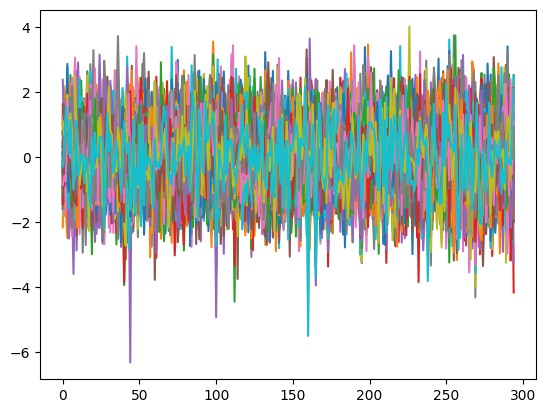

In [39]:
plt.plot(data[:, :100]);